In [1]:
# ============================================================
# Cálculo de SPI y métricas de sequía
# Equivalente simplificado del script R usando Python
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import gamma, norm


# ------------------------------------------------------------
# 1. Cargar datos de precipitación
# ------------------------------------------------------------
def cargar_precipitacion(ruta_csv, columnas_precipitacion=None):
    """
    Lee el archivo CSV de precipitación.

    Si columnas_precipitacion=None, se omite la primera columna,
    siguiendo la lógica del script R: datam[, 2:ncol(datam)].
    """
    df = pd.read_csv(ruta_csv)

    if columnas_precipitacion is None:
        return df.iloc[:, 1:]

    return df[columnas_precipitacion]


# ------------------------------------------------------------
# 2. Calcular SPI para una serie
# ------------------------------------------------------------
def calcular_spi_serie(precipitacion, escala=3):
    """
    Calcula SPI usando acumulados móviles y distribución Gamma.

    Parámetros
    ----------
    precipitacion : pd.Series
        Serie mensual de precipitación.
    escala : int
        Escala temporal del SPI: 3, 6, 12, etc.

    Retorna
    -------
    pd.Series con valores SPI.
    """

    serie = pd.Series(precipitacion, dtype="float64")

    # Acumulado móvil de precipitación
    acumulado = serie.rolling(window=escala, min_periods=escala).sum()

    # Valores válidos para ajustar Gamma
    valores = acumulado.dropna()
    valores = valores[valores > 0]

    spi = pd.Series(np.nan, index=serie.index)

    if len(valores) < 5:
        return spi

    # Ajuste Gamma con loc fijo en 0
    shape, loc, scale_param = gamma.fit(valores, floc=0)

    # Probabilidad acumulada Gamma
    prob = gamma.cdf(acumulado, a=shape, loc=loc, scale=scale_param)

    # Evitar infinitos en la transformación normal
    prob = np.clip(prob, 1e-6, 1 - 1e-6)

    # Transformación a distribución normal estándar
    spi[:] = norm.ppf(prob)

    return spi


# ------------------------------------------------------------
# 3. Calcular SPI para todas las estaciones o regiones
# ------------------------------------------------------------
def calcular_spi_dataframe(df_precipitacion, escala=3):
    """
    Calcula SPI para todas las columnas del DataFrame.
    """

    spi_df = df_precipitacion.apply(
        lambda col: calcular_spi_serie(col, escala=escala),
        axis=0
    )

    return spi_df


# ------------------------------------------------------------
# 4. Identificar grupos consecutivos en una condición booleana
# ------------------------------------------------------------
def grupos_consecutivos(condicion):
    """
    Identifica bloques consecutivos True en una serie booleana.
    Retorna una lista de arreglos con las posiciones de cada bloque.
    """

    condicion = np.asarray(condicion, dtype=bool)

    if condicion.sum() == 0:
        return []

    cambios = np.diff(condicion.astype(int))

    inicios = np.where(cambios == 1)[0] + 1
    finales = np.where(cambios == -1)[0] + 1

    if condicion[0]:
        inicios = np.r_[0, inicios]

    if condicion[-1]:
        finales = np.r_[finales, len(condicion)]

    return [np.arange(i, f) for i, f in zip(inicios, finales)]


# ------------------------------------------------------------
# 5. Calcular duración, severidad, intensidad e interarrival
# ------------------------------------------------------------
def calcular_metricas_sequia(spi, escala=3, umbral=-0.84):
    """
    Calcula métricas de sequía para una serie SPI.

    Duración:
        Número de meses consecutivos con SPI < umbral.

    Severidad:
        Suma negativa del SPI durante el evento.

    Intensidad:
        Valor mínimo de SPI durante el evento.

    Interarrival:
        Tiempo entre inicios de eventos consecutivos.
    """

    serie = pd.Series(spi, dtype="float64").iloc[escala - 1:].reset_index(drop=True)

    condicion_sequia = serie < umbral
    eventos = grupos_consecutivos(condicion_sequia)

    if len(eventos) == 0:
        return {
            "duracion": pd.Series(dtype="float64"),
            "severidad": pd.Series(dtype="float64"),
            "intensidad": pd.Series(dtype="float64"),
            "interarrival": pd.Series(dtype="float64")
        }

    duracion = np.array([len(e) for e in eventos], dtype=float)
    severidad = np.array([-serie.iloc[e].sum() for e in eventos], dtype=float)
    intensidad = np.array([serie.iloc[e].min() for e in eventos], dtype=float)

    inicios = np.array([e[0] for e in eventos])

    if len(inicios) > 1:
        interarrival = np.diff(inicios).astype(float)
    else:
        interarrival = np.array([], dtype=float)

    return {
        "duracion": pd.Series(duracion),
        "severidad": pd.Series(severidad),
        "intensidad": pd.Series(intensidad),
        "interarrival": pd.Series(interarrival)
    }


# ------------------------------------------------------------
# 6. Aplicar métricas a todas las columnas SPI
# ------------------------------------------------------------
def calcular_metricas_dataframe(spi_df, escala=3, umbral=-0.84):
    """
    Calcula métricas de sequía para todas las columnas del DataFrame SPI.
    """

    resultados = {
        "duracion": {},
        "severidad": {},
        "intensidad": {},
        "interarrival": {}
    }

    for columna in spi_df.columns:
        metricas = calcular_metricas_sequia(
            spi=spi_df[columna],
            escala=escala,
            umbral=umbral
        )

        for nombre_metrica, valores in metricas.items():
            resultados[nombre_metrica][columna] = valores.reset_index(drop=True)

    return {
        nombre: pd.DataFrame(diccionario)
        for nombre, diccionario in resultados.items()
    }


# ------------------------------------------------------------
# 7. Guardar resultados recortando filas vacías
# ------------------------------------------------------------
def guardar_metricas(metricas, prefijo_salida):
    """
    Guarda duración, severidad, intensidad e interarrival en CSV.
    """

    max_filas = max(
        df.notna().sum().max()
        for df in metricas.values()
        if not df.empty
    )

    for nombre, df in metricas.items():
        salida = df.iloc[:max_filas, :]
        salida.to_csv(f"{prefijo_salida}_{nombre}.csv", index=False)


# ------------------------------------------------------------
# 8. Flujo principal
# ------------------------------------------------------------
def ejecutar_analisis_spi(
    ruta_csv,
    escala=3,
    umbral=-0.84,
    nombre_salida_spi="spi3_mantaro.csv",
    prefijo_metricas="spi3"
):
    """
    Ejecuta todo el análisis:
    1. Lee precipitación.
    2. Calcula SPI.
    3. Calcula métricas de sequía.
    4. Guarda resultados.
    """

    precipitacion = cargar_precipitacion(ruta_csv)

    spi_df = calcular_spi_dataframe(precipitacion, escala=escala)
    spi_df.to_csv(nombre_salida_spi, index=False)

    metricas = calcular_metricas_dataframe(
        spi_df=spi_df,
        escala=escala,
        umbral=umbral
    )

    guardar_metricas(metricas, prefijo_salida=prefijo_metricas)

    return spi_df, metricas



In [3]:
# ------------------------------------------------------------
# Ejemplo de uso
# ------------------------------------------------------------
if __name__ == "__main__":

    spi_df, metricas = ejecutar_analisis_spi(
        ruta_csv="../Data/REg_prec.csv",
        escala=3,
        umbral=-0.84,
        nombre_salida_spi="spi3_mantaro.csv",
        prefijo_metricas="spi3"
    )

    print("SPI calculado:")
    print(spi_df.head())

    print("\nDuración:")
    print(metricas["duracion"].head())

SPI calculado:
         R1        R2        R3        R4
0       NaN       NaN       NaN       NaN
1       NaN       NaN       NaN       NaN
2  1.268444  1.072471  1.295314  1.621017
3  0.876237  0.634322  0.767733  0.836475
4  0.527390  0.343798  0.190249  0.357679

Duración:
    R1   R2   R3   R4
0  3.0  2.0  2.0  2.0
1  3.0  6.0  4.0  3.0
2  3.0  2.0  3.0  3.0
3  1.0  2.0  2.0  1.0
4  4.0  3.0  3.0  3.0


In [4]:
import matplotlib.pyplot as plt
import pandas as pd


def graficar_metrica(metricas, nombre_metrica, figsize=(10, 5)):
    """
    Grafica una métrica de sequía para todas las estaciones.

    Parámetros
    ----------
    metricas : dict
        Diccionario generado por calcular_metricas_dataframe().
        Debe contener claves como 'duracion', 'severidad',
        'intensidad' e 'interarrival'.

    nombre_metrica : str
        Nombre de la métrica a graficar.

    figsize : tuple
        Tamaño de la figura.

    Retorna
    -------
    None
    """

    df = metricas[nombre_metrica]

    plt.figure(figsize=figsize)

    for columna in df.columns:
        plt.plot(df[columna], marker="o", label=columna)

    plt.title(f"Métrica de sequía: {nombre_metrica}")
    plt.xlabel("Número de evento")
    plt.ylabel(nombre_metrica.capitalize())
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def graficar_metricas_todas(metricas, figsize=(10, 5)):
    """
    Grafica todas las métricas disponibles en figuras separadas.

    Parámetros
    ----------
    metricas : dict
        Diccionario con los DataFrames de métricas.

    figsize : tuple
        Tamaño de cada figura.

    Retorna
    -------
    None
    """

    for nombre_metrica in metricas.keys():
        graficar_metrica(
            metricas=metricas,
            nombre_metrica=nombre_metrica,
            figsize=figsize
        )


def graficar_boxplot_metricas(metricas, figsize=(8, 5)):
    """
    Genera boxplots para comparar estaciones por cada métrica.

    Parámetros
    ----------
    metricas : dict
        Diccionario con métricas de sequía.

    figsize : tuple
        Tamaño de cada figura.

    Retorna
    -------
    None
    """

    for nombre_metrica, df in metricas.items():
        plt.figure(figsize=figsize)

        df.boxplot()

        plt.title(f"Distribución de {nombre_metrica}")
        plt.xlabel("Estación o región")
        plt.ylabel(nombre_metrica.capitalize())
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()


def graficar_histograma_metrica(metricas, nombre_metrica, bins=10, figsize=(8, 5)):
    """
    Grafica un histograma combinado de una métrica.

    Parámetros
    ----------
    metricas : dict
        Diccionario con métricas de sequía.

    nombre_metrica : str
        Métrica a graficar.

    bins : int
        Número de intervalos del histograma.

    figsize : tuple
        Tamaño de la figura.

    Retorna
    -------
    None
    """

    df = metricas[nombre_metrica]

    valores = df.to_numpy().ravel()
    valores = valores[pd.notna(valores)]

    plt.figure(figsize=figsize)
    plt.hist(valores, bins=bins)

    plt.title(f"Histograma de {nombre_metrica}")
    plt.xlabel(nombre_metrica.capitalize())
    plt.ylabel("Frecuencia")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def graficar_resumen_metricas(metricas, estacion, figsize=(8, 5)):
    """
    Grafica un resumen de métricas para una estación específica.

    Parámetros
    ----------
    metricas : dict
        Diccionario con métricas de sequía.

    estacion : str
        Nombre de la columna o estación a graficar.

    figsize : tuple
        Tamaño de cada figura.

    Retorna
    -------
    None
    """

    for nombre_metrica, df in metricas.items():

        if estacion not in df.columns:
            raise ValueError(f"La estación '{estacion}' no existe en {nombre_metrica}.")

        plt.figure(figsize=figsize)

        plt.plot(df[estacion], marker="o")

        plt.title(f"{nombre_metrica.capitalize()} - {estacion}")
        plt.xlabel("Número de evento")
        plt.ylabel(nombre_metrica.capitalize())
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

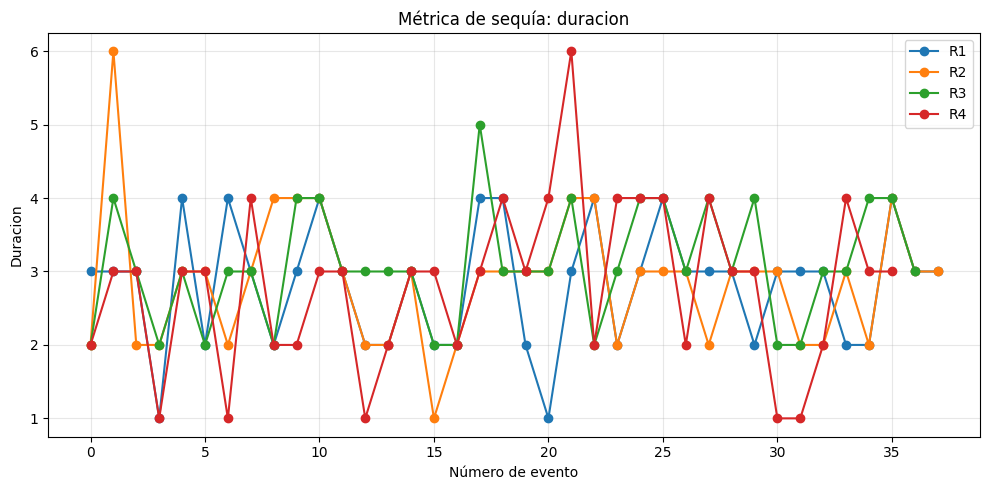

In [5]:
graficar_metrica(metricas, "duracion")

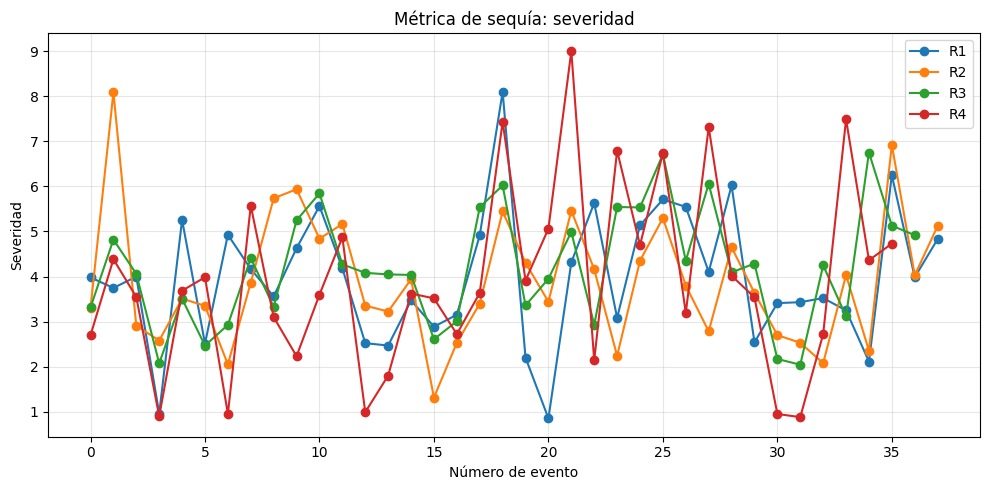

In [6]:
graficar_metrica(metricas, "severidad")

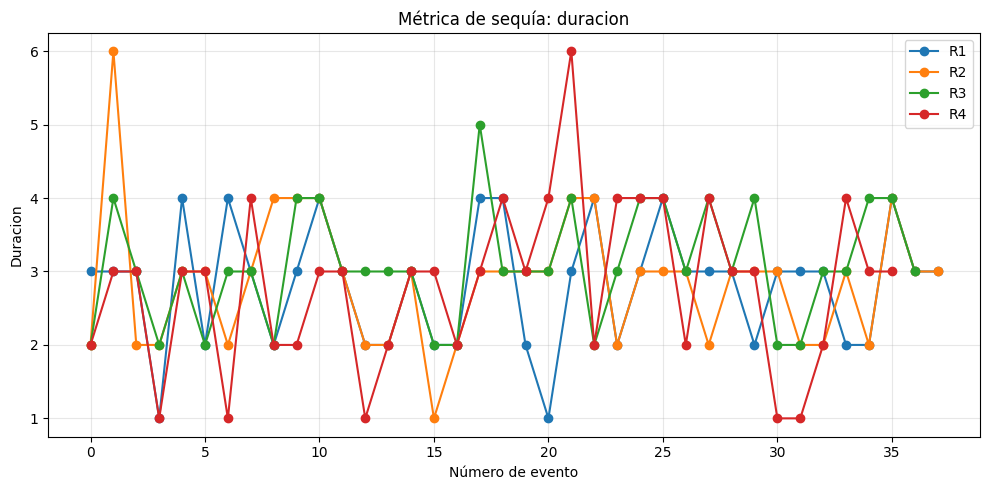

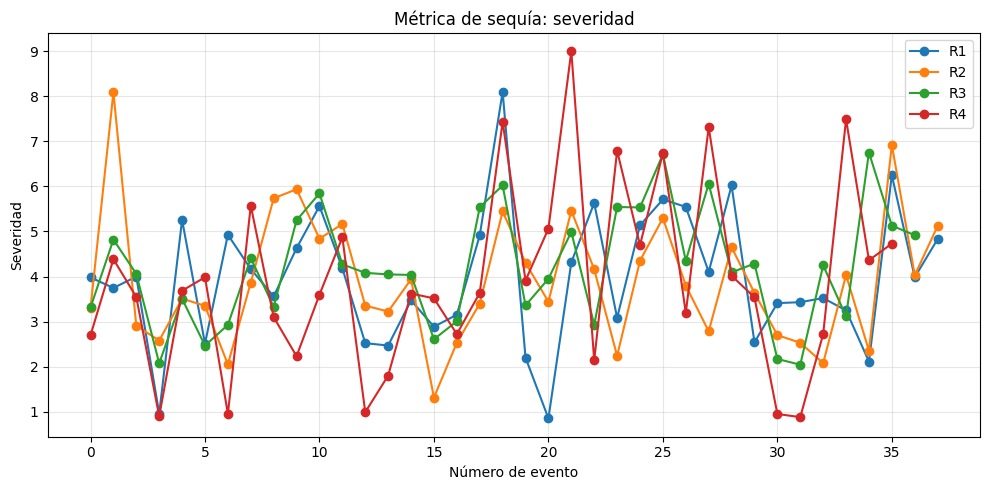

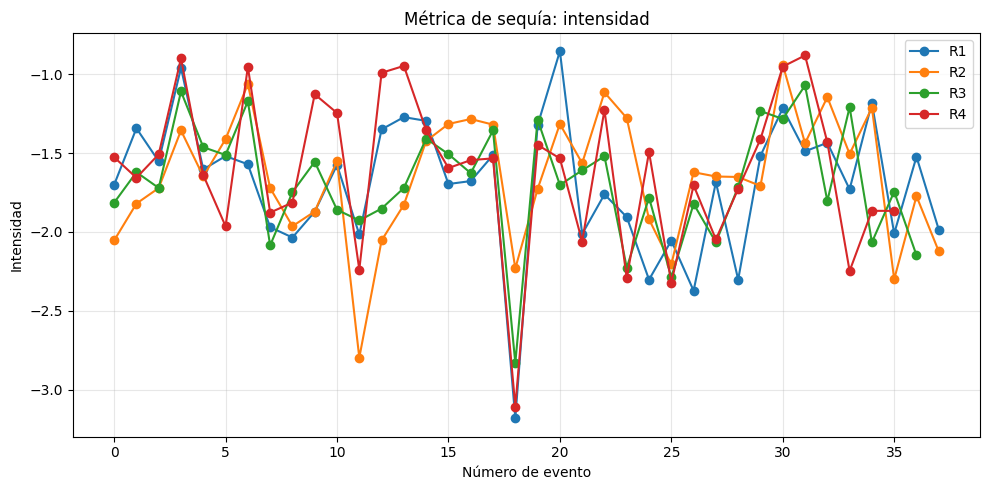

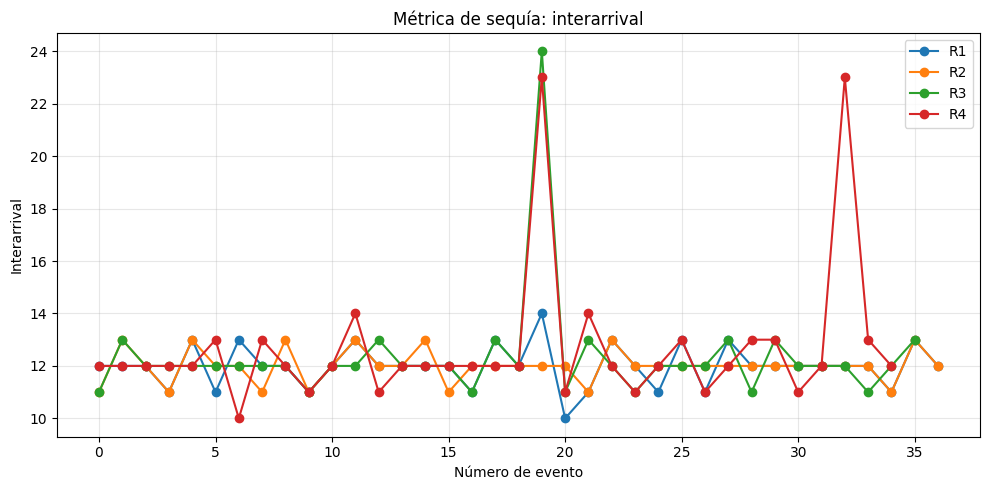

In [7]:
graficar_metricas_todas(metricas)

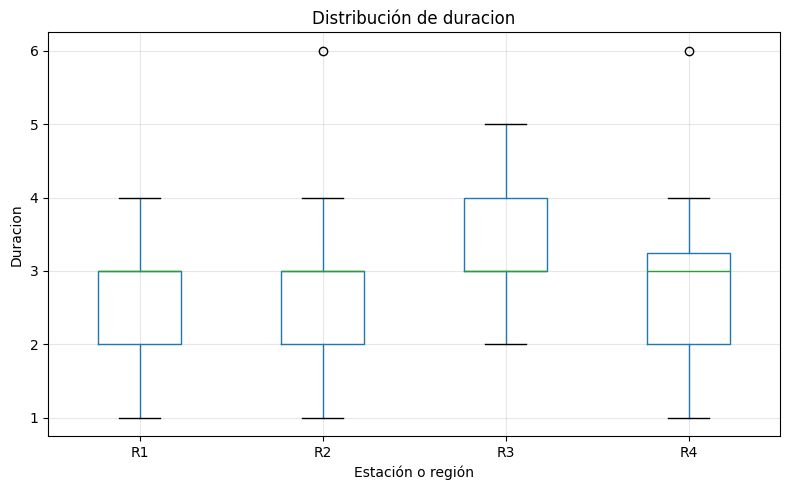

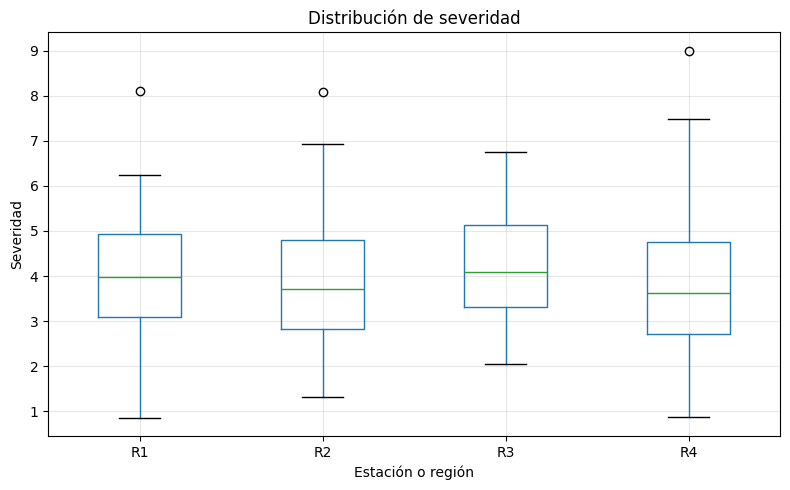

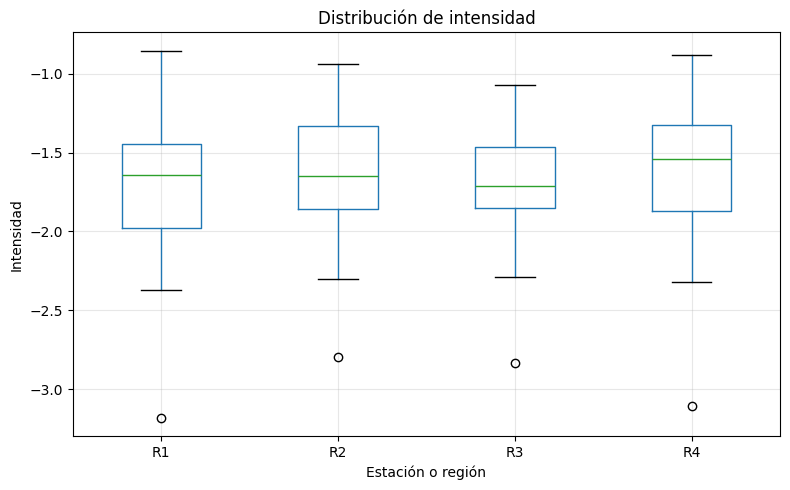

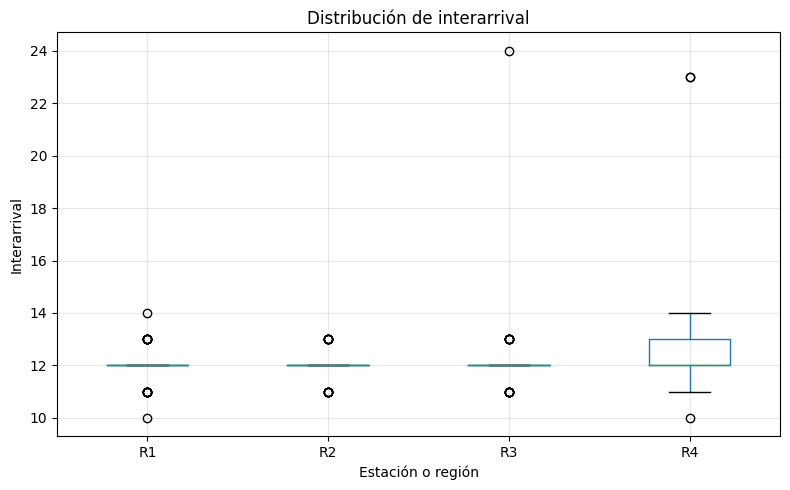

In [8]:
graficar_boxplot_metricas(metricas)

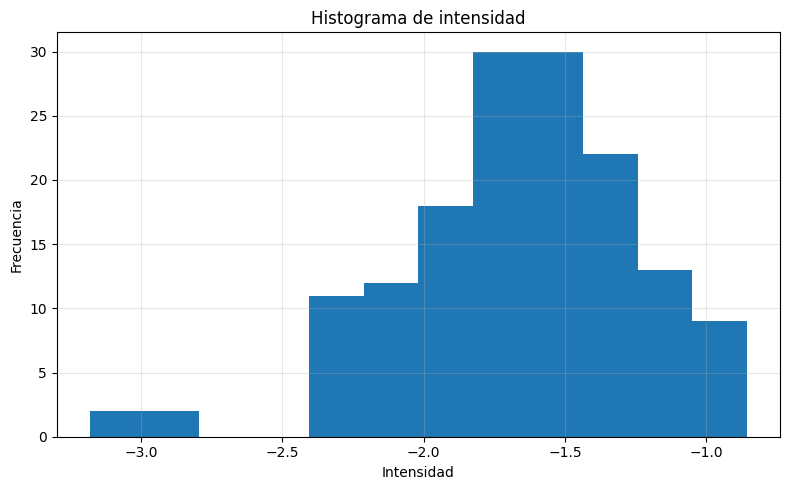

In [9]:
graficar_histograma_metrica(metricas, "intensidad", bins=12)